# Sistemas de Múltiplos Classificadores

Multiple Classifier System (MCS)

***

In [210]:
!pip install ucimlrepo

In [211]:
# importando as bibliotecas
import pandas as pd
import matplotlib.pyplot as plt

# Funções de avaliação dos modelos
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import BaggingClassifier
from sklearn.neighbors import KNeighborsClassifier

# visualização da árvore
from sklearn.tree import plot_tree

seed = 42

## Conjunto de dados

In [212]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
iris = fetch_ucirepo(id=53)

# data (as pandas dataframes)
X = iris.data.features
y = iris.data.targets

dataset = pd.concat([X,y], axis=1)
dataset

,sepal length,sepal width,petal length,petal width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [213]:
X = dataset.drop([dataset.columns[-1]], axis = 1)
y = dataset[dataset.columns[-1]]

In [214]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,  random_state=seed)
X_train.shape, X_test.shape

((105, 4), (45, 4))

## Bagging (Bootstrap aggregation)


Vamos avaliar o $RandomForest$

$RandomForest$ é um meta estimador que ajusta vários classificadores de árvore de decisão em várias subamostras do conjunto de dados e usa a **média** para melhorar a precisão preditiva e controlar o ajuste excessivo.

 O tamanho da subamostra é controlado com o parâmetro $max\_samples$ se $bootstrap=True$ (padrão), caso contrário, todo o conjunto de dados é usado para construir cada árvore.

Alguns parâmetros que vamos ajustar:

 - `n_estimators`: define o número de árvores. Por padrão 100.
 - `criterion`: função de medida da qualidade do split.  Valores possíveis: {“gini”, “entropy”, “log_loss”}
 - `max_depth`: A profundidade máxima da árvore

Confira demais parâmetros [aqui](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)


In [215]:
from sklearn.ensemble import RandomForestClassifier

In [216]:
model = RandomForestClassifier(random_state=seed, max_depth=2)

#treinando o modelo
model.fit(X_train, y_train)

#Resultados do classificador
print(model.get_params())

{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 2, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}


In [217]:
#Resultados do classificador
print(classification_report(y_test, model.predict(X_test)))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        19
Iris-versicolor       1.00      1.00      1.00        13
 Iris-virginica       1.00      1.00      1.00        13

       accuracy                           1.00        45
      macro avg       1.00      1.00      1.00        45
   weighted avg       1.00      1.00      1.00        45



**Vamos visualizar as 3 primeiras árvores**

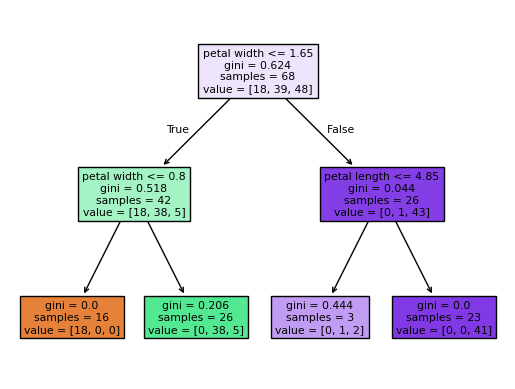

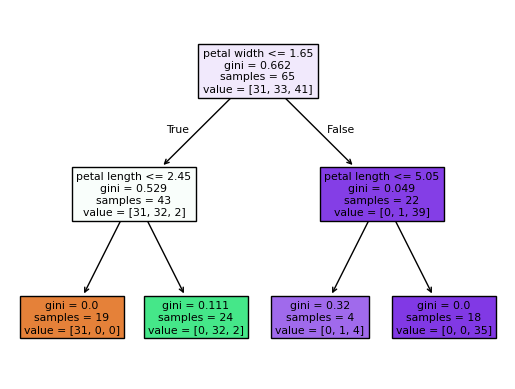

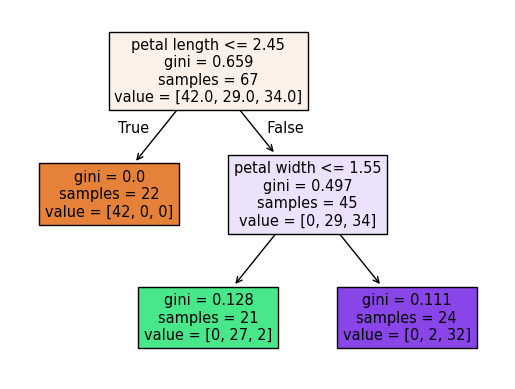

In [218]:
for i in range(3):
    tree = model.estimators_[i]
    # Retorna uma lista contendo os dados para as caixas de anotação que compõem a árvore
    tree = plot_tree(tree, feature_names=X_train.columns, filled=True)
    plt.show()


### Ajuste de parâmetros

In [219]:
model = RandomForestClassifier(random_state=seed)


parameters = {'n_estimators': [50, 100, 150, 200],
              'criterion': ['gini', 'entropy'],
              'max_depth': [2, 4, 6, 8]
              }

grid = GridSearchCV(estimator = model,
                    param_grid = parameters,
                    scoring = 'accuracy',          # métrica de avaliação
                    cv = 5)                        # cross-validation

grid.fit(X_train, y_train)

y_pred = grid.predict(X_test)

print("Melhor parametro:", grid.best_params_)

Melhor parametro: {'criterion': 'gini', 'max_depth': 2, 'n_estimators': 150}


In [220]:
#Modelo final com os melhores parâmetros selecionados
model = grid.best_estimator_

print(model)

#treinando o modelo
model.fit(X_train, y_train)

#Resultados do classificador
print(classification_report(y_test, model.predict(X_test)))

RandomForestClassifier(max_depth=2, n_estimators=150, random_state=42)
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        19
Iris-versicolor       1.00      1.00      1.00        13
 Iris-virginica       1.00      1.00      1.00        13

       accuracy                           1.00        45
      macro avg       1.00      1.00      1.00        45
   weighted avg       1.00      1.00      1.00        45



Agora vamos aplicar um bagging...

In [221]:
bagging_knn_classifier = BaggingClassifier(estimator=KNeighborsClassifier(),
                                           n_estimators=100,
                                           random_state=seed)
bagging_knn_classifier.fit(X_train, y_train)
y_pred_bagging_knn = bagging_knn_classifier.predict(X_test)

print(classification_report(y_test, y_pred_bagging_knn))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        19
Iris-versicolor       1.00      1.00      1.00        13
 Iris-virginica       1.00      1.00      1.00        13

       accuracy                           1.00        45
      macro avg       1.00      1.00      1.00        45
   weighted avg       1.00      1.00      1.00        45



 Também podemos utilizar um [VotingClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.VotingClassifier.html)

In [222]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import VotingClassifier

# Criar os Modelos Heterogêneos
model1 = DecisionTreeClassifier(random_state=seed)
model2 = SVC(probability=True, random_state=seed)
model3 = KNeighborsClassifier()

# Aplicar Ensemble com VotingClassifier
voting_clf = VotingClassifier(
    estimators=[('dt', model1), ('svc', model2), ('knn', model3)],
    voting='soft'  # Usar 'soft' para votar com base nas probabilidades
    # If ‘hard’, uses predicted class labels for majority rule voting.
    # Else if ‘soft’, predicts the class label based on the argmax of the sums of the predicted probabilities,
    # which is recommended for an ensemble of well-calibrated classifiers.
)

# Treinar o modelo ensemble
voting_clf.fit(X_train, y_train)

print(classification_report(y_test, voting_clf.predict(X_test)))

print("Acurácias individuais...")
# Avaliar o desempenho dos modelos individuais
for name, model in voting_clf.named_estimators_.items():
    model.fit(X_train, y_train)
    y_pred_individual = model.predict(X_test)
    accuracy_individual = accuracy_score(y_test, y_pred_individual)
    print(f"Acurácia do {name}: {accuracy_individual:.2f}")


                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        19
Iris-versicolor       1.00      1.00      1.00        13
 Iris-virginica       1.00      1.00      1.00        13

       accuracy                           1.00        45
      macro avg       1.00      1.00      1.00        45
   weighted avg       1.00      1.00      1.00        45

Acurácias individuais...
Acurácia do dt: 1.00
Acurácia do svc: 1.00
Acurácia do knn: 1.00


## Boosting

Vamos avaliar dois modelos:

[**AdaBoost (Adaptive Boosting)**](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.AdaBoostClassifier.html): meta-estimador que começa ajustando um classificador no conjunto de dados original e, em seguida, ajusta cópias adicionais do classificador no mesmo conjunto de dados, mas onde os pesos das instâncias classificadas incorretamente são ajustados de forma que os classificadores subsequentes se concentrem mais em casos difíceis.

- Ajusta iterativamente o peso dos exemplos de treinamento com base na dificuldade de classificação. Modelos subsequentes são treinados para corrigir erros dos modelos anteriores.
- Foca em corrigir os erros dos modelos anteriores através do ajuste de pesos dos exemplos classificados incorretamente.
- Combina vários classificadores "fracos" para criar um classificador "forte".

[**XGBoost (Stochastic Gradient Boosting)**](https://xgboost.readthedocs.io/en/stable/): meta-estimador baseado em Decision Trees (árvores de decisão) com Gradient Boosting (aumento de gradiente).

-  Usa o método de boosting baseado em gradiente, onde novos modelos são adicionados para corrigir os erros dos modelos anteriores, mas otimiza a função objetivo com uma abordagem de gradient descent e regularização.
- Minimiza uma função de perda com regularização para melhorar a precisão e reduzir o overfitting.


### Adaboost

In [223]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

In [224]:
model = AdaBoostClassifier(estimator=None, random_state=seed)
#Quando você não fornece um estimador base, o AdaBoostClassifier usa o DecisionTreeClassifier com max_depth=1 como estimador padrão.

#treinando o modelo
model.fit(X_train, y_train)

#Salvando as predições
y_pred = model.predict(X_test)

print("Parâmetros\n")
print(model.get_params())

print("\nEstimator\n")
print(model.estimator_)

#Resultados do classificador
print(classification_report(y_test, model.predict(X_test)))

Parâmetros

{'algorithm': 'deprecated', 'estimator': None, 'learning_rate': 1.0, 'n_estimators': 50, 'random_state': 42}

Estimator

DecisionTreeClassifier(max_depth=1)
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        19
Iris-versicolor       1.00      1.00      1.00        13
 Iris-virginica       1.00      1.00      1.00        13

       accuracy                           1.00        45
      macro avg       1.00      1.00      1.00        45
   weighted avg       1.00      1.00      1.00        45



_The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning._

SAMME:
- Stagewise Additive Modeling using a Multiclass Exponential loss function
- Versão multiclasse do AdaBoost original
- Os pesos das amostras são ajustados em cada iteração, e o modelo final é uma combinação ponderada dos classificadores

SAMME.R:
- "R" em SAMME.R significa "Real"
- Versão variante do SAMME que utiliza as probabilidades preditas em vez das classes previstas diretamente para atualizar os pesos das amostras

**Vamos comparar o desempenho dele com uma árvore de decisão**

In [225]:
model_dt = DecisionTreeClassifier(max_depth=1, random_state=seed)

#treinando o modelo
model_dt = model_dt.fit(X_train, y_train)

#Salvando as predições
y_pred_dt = model_dt.predict(X_test)

Matriz de Confusão SEM Adaboost:
Acurácia SEM Adaboost: 71.11
Matriz de Confusão COM Adaboost:
Acurácia COM Adaboost: 100.00


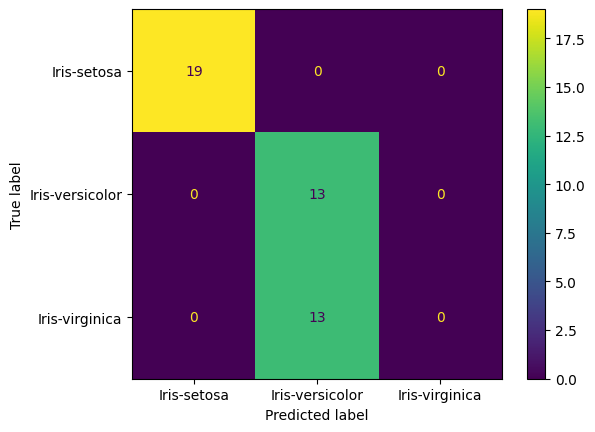

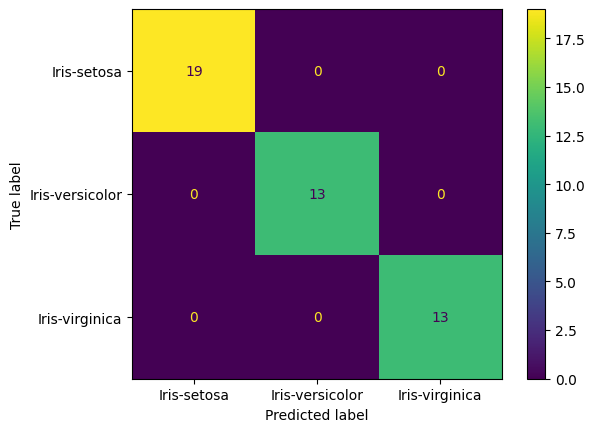

In [226]:
print("Matriz de Confusão SEM Adaboost:")
disp_cm = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_pred_dt, labels=model_dt.classes_),
                                 display_labels=model.classes_)
disp_cm.plot()
# print(confusion_matrix(y_test, y_pred_dt))
print("Acurácia SEM Adaboost: %.2f" % (accuracy_score(y_test, y_pred_dt)*100))

print("Matriz de Confusão COM Adaboost:")
disp_cm = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_pred, labels=model.classes_),
                                 display_labels=model.classes_)
disp_cm.plot()
print("Acurácia COM Adaboost: %.2f" % (accuracy_score(y_test, y_pred)*100))

**Como é possível observar, a adição do Adaboost ao classificador melhora muito sua eficiência.**

**Além disso, abaixo é mostrada a utilização do Adaboost, porém com outro tipo de classificador.**

In [227]:
# Classes do modelo
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

In [228]:
base_estimator = SVC(kernel='linear', probability=True, random_state=seed)

model = base_estimator.fit(X_train, y_train)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

model_ada = AdaBoostClassifier(base_estimator, random_state=seed)
model_ada.fit(X_train, y_train)
y_pred_ada = model_ada.predict(X_test)

print("Acurácias")
print("SVM: %.2f" % (accuracy_score(y_test, y_pred)*100))
print("SVM + Adaboost: %.2f" % (accuracy_score(y_test, y_pred_ada)*100))

Acurácias
SVM: 100.00
SVM + Adaboost: 97.78


In [229]:
base_estimator = LogisticRegression(random_state=seed)

model = base_estimator.fit(X_train, y_train)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

model_ada = AdaBoostClassifier(base_estimator, random_state=seed)
model_ada.fit(X_train, y_train)
y_pred_ada = model_ada.predict(X_test)

print("Acurácias")
print("LogisticR: %.2f" % (accuracy_score(y_test, y_pred)*100))
print("LogisticR + Adaboost: %.2f" % (accuracy_score(y_test, y_pred_ada)*100))

Acurácias
LogisticR: 100.00
LogisticR + Adaboost: 82.22


**Disclaimer**: *O AdaBoost foi originalmente projetado para combinar classificadores fracos. SVM e Regressão Logística são considerados classificadores fortes, o que significa que eles já têm um bom desempenho por conta própria. Quando AdaBoost tenta "reforçar" esses modelos, ele pode introduzir ruído ou sobreajuste.*

### XGBoost

Documentação [link](https://xgboost.readthedocs.io/en/stable/).


In [230]:
# Instalando a biblioteca
# !pip install xgboost

In [231]:
from xgboost import XGBClassifier

In [232]:
model = XGBClassifier(random_state=seed)

print("Parâmetros\n")
print(model.get_params())

Parâmetros

{'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': None, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': None, 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': None, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': None, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': None, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': None, 'tree_method': None, 'validate_parameters': None, 'verbosity': None}


In [233]:
# #treinando o modelo
# model.fit(X_train, y_train)

# #Resultados do classificador
# print(model)
# print()

# #Resultados do classificador
# print(classification_report(y_test, model.predict(X_test)))

In [234]:
y_train_ = y_train.map({'Iris-setosa':0,'Iris-versicolor':1, 'Iris-virginica':2})
y_test_ = y_test.map({'Iris-setosa':0,'Iris-versicolor':1, 'Iris-virginica': 2})
# map() é útil quando a série (vetor) é PEQUENA e CONHECIDA

In [235]:
# Problemas de classificação multi-class
model = XGBClassifier(objective="multi:softmax",num_class=3, random_state=seed)

#treinando o modelo
model.fit(X_train, y_train_)


#Resultados do classificador
print(classification_report(y_test_, model.predict(X_test)))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



### CatBoost

Documentação [link](https://catboost.ai/docs/en/concepts/python-reference_catboostclassifier).

In [236]:
!pip install catboost

In [237]:
from catboost import CatBoostClassifier

model = CatBoostClassifier(
    iterations=100,
    learning_rate=0.1,
    depth=8,
    verbose=1,  # Set to a positive integer to see training progress
    random_state=seed
)
model.fit(X_train, y_train)

print(classification_report(y_test, model.predict(X_test)))

0:	learn: 1.0206460	total: 2.97ms	remaining: 294ms
1:	learn: 0.9256637	total: 4.07ms	remaining: 199ms
2:	learn: 0.8556349	total: 5.36ms	remaining: 173ms
3:	learn: 0.7919830	total: 6.59ms	remaining: 158ms
4:	learn: 0.7299263	total: 7.77ms	remaining: 148ms
5:	learn: 0.6870954	total: 9.02ms	remaining: 141ms
6:	learn: 0.6384834	total: 10.2ms	remaining: 135ms
7:	learn: 0.6040585	total: 11.4ms	remaining: 131ms
8:	learn: 0.5701367	total: 12.1ms	remaining: 123ms
9:	learn: 0.5353130	total: 14.2ms	remaining: 128ms
10:	learn: 0.5054403	total: 14.9ms	remaining: 120ms
11:	learn: 0.4760119	total: 16.1ms	remaining: 118ms
12:	learn: 0.4524960	total: 17.4ms	remaining: 117ms
13:	learn: 0.4219350	total: 17.6ms	remaining: 108ms
14:	learn: 0.3985433	total: 18.8ms	remaining: 106ms
15:	learn: 0.3779524	total: 19.4ms	remaining: 102ms
16:	learn: 0.3612115	total: 20.6ms	remaining: 101ms
17:	learn: 0.3472022	total: 21.8ms	remaining: 99.2ms
18:	learn: 0.3256544	total: 22.2ms	remaining: 94.6ms
19:	learn: 0.3128652

## Outro Dataset (Wine Quality)

In [238]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
wine_quality = fetch_ucirepo(id=186)

# data (as pandas dataframes)
X = wine_quality.data.features
y = wine_quality.data.targets


dataset = pd.concat([X,y], axis=1)
dataset

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
6492,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6
6493,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5
6494,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6
6495,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7


In [239]:
#Mapeando atributo qualidade para binário de 0 a 6 => 0 e de 6 a 10 => 1
dataset['quality'] = dataset['quality'].map({1:0,2:0,3:0,4:0,5:0,6:1,7:1,8:1,9:1})
dataset['quality'].value_counts()

,count
quality,
1,4113
0,2384


In [240]:
X = dataset.drop([dataset.columns[-1]], axis = 1)
y = dataset[dataset.columns[-1]]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)
X_train.shape, X_test.shape
y_train.value_counts()
y_test.value_counts()

,count
quality,
1,1259
0,691


In [241]:
model_dt = DecisionTreeClassifier(max_depth=4, random_state=seed)

#treinando o modelo
model_dt = model_dt.fit(X_train, y_train)

print(classification_report(y_test, model_dt.predict(X_test)))

              precision    recall  f1-score   support

           0       0.62      0.54      0.58       691
           1       0.76      0.82      0.79      1259

    accuracy                           0.72      1950
   macro avg       0.69      0.68      0.68      1950
weighted avg       0.71      0.72      0.71      1950



In [242]:
model = RandomForestClassifier(random_state=seed, max_depth=4)

#treinando o modelo
model.fit(X_train, y_train)

#Resultados do classificador
print(model)

#Resultados do classificador
print(classification_report(y_test, model.predict(X_test)))

RandomForestClassifier(max_depth=4, random_state=42)
              precision    recall  f1-score   support

           0       0.68      0.58      0.63       691
           1       0.79      0.85      0.82      1259

    accuracy                           0.75      1950
   macro avg       0.73      0.72      0.72      1950
weighted avg       0.75      0.75      0.75      1950



In [243]:
# Problemas de classificação multi-class
model = XGBClassifier(objective="binary:logistic", random_state=seed)

#treinando o modelo
model.fit(X_train, y_train)

#Resultados do classificador
print(classification_report(y_test, model.predict(X_test)))

              precision    recall  f1-score   support

           0       0.72      0.72      0.72       691
           1       0.85      0.85      0.85      1259

    accuracy                           0.80      1950
   macro avg       0.78      0.78      0.78      1950
weighted avg       0.80      0.80      0.80      1950



In [244]:
from catboost import CatBoostClassifier

model = CatBoostClassifier(
    #iterations=500,
    #learning_rate=0.1,
    #depth=6,
    verbose=1,  # Set to a positive integer to see training progress
    random_state=seed
)
model.fit(X_train, y_train)

print(classification_report(y_test, model.predict(X_test)))

Learning rate set to 0.019669
0:	learn: 0.6860065	total: 11.1ms	remaining: 11.1s
1:	learn: 0.6799224	total: 22.7ms	remaining: 11.3s
2:	learn: 0.6730882	total: 35.1ms	remaining: 11.7s
3:	learn: 0.6673397	total: 47.8ms	remaining: 11.9s
4:	learn: 0.6606941	total: 56.9ms	remaining: 11.3s
5:	learn: 0.6550040	total: 67ms	remaining: 11.1s
6:	learn: 0.6495682	total: 77.2ms	remaining: 10.9s
7:	learn: 0.6438250	total: 94.2ms	remaining: 11.7s
8:	learn: 0.6391431	total: 104ms	remaining: 11.5s
9:	learn: 0.6331935	total: 114ms	remaining: 11.3s
10:	learn: 0.6281811	total: 125ms	remaining: 11.3s
11:	learn: 0.6233581	total: 134ms	remaining: 11s
12:	learn: 0.6195560	total: 138ms	remaining: 10.5s
13:	learn: 0.6153231	total: 141ms	remaining: 9.93s
14:	learn: 0.6107513	total: 144ms	remaining: 9.47s
15:	learn: 0.6064455	total: 147ms	remaining: 9.06s
16:	learn: 0.6020872	total: 151ms	remaining: 8.76s
17:	learn: 0.5983168	total: 155ms	remaining: 8.46s
18:	learn: 0.5950527	total: 158ms	remaining: 8.17s
19:	lea